# Oppgave 1

## 1a) Les og forstå data

In [70]:
import numpy as np 
import pandas as pd


In [71]:
path = "../data/train.csv"
df = pd.read_csv(path, header=0)
df.head()
df = df.set_index("PassengerId")
print(f"Antall observasjoner: {len(df)}")
df.head()

Antall observasjoner: 891


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Notater

- NaN verdier i age
- Må forstå hva radene representerer

Rader:
- PassengerId: Indeksering/nummerering av passasjerer.
- Survided: Død=0, overlevelse=1
- Pclass: Billett-klasse. 1 er best, 3 er dårligst
- Name: Navn på passasjeren
- Sex: Kjønn, mann/kvinne. Må konverteres til kategorisk variabel
- Age: Alder på passasjer. Må håndtere NaN verdier
- SibSp: Antall søsken/partnere ombord Titanic
- Parch: Antall foreldre/barn ombord Titanic
- Ticket: Billettnummer
- Fare: Pris betalt for reisen
- Cabin: Kabin-nummer
- Embarked: Havn for påstigning. C=Cherbourg, Q=Queenstown, S=Southampton



## 1b) Håndtering av manglende alder-data

In [72]:
display(df.isnull().sum())

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [73]:
df_remove_nan = df.dropna(subset="Age")

mean = np.mean(df_remove_nan["Age"]).round()
# print(mean)
df_mean_nan = df.copy()
df_mean_nan["Age"] = df_mean_nan.groupby\
    (["Pclass", "Sex"],group_keys=False)["Age"].apply(lambda x: x.fillna(x.median()))

# display(df_remove_nan.head(10))
# display(df_mean_nan.head(10))
# display(df.head(10))

### Notater
- Siden det er få observasjoner, utgjør rader med NaN verdier i alder en stor andel av radene.
- Lager to mulige dataframes, en hvor rader med NaN fjernes, og en hvor NaN alder erstattes med gjennomsnittlig alder

## 1c) One hot encoding av kategoriske data

In [74]:
df = df_mean_nan
categorical_cols = ["Pclass", "Sex", "Embarked"]
df = pd.get_dummies(df, columns=categorical_cols, prefix=categorical_cols)
# display(df.head())


### Notater
- Velger dataframe der NaN alder er erstattet med gjennomsnittlig alder for person og klasse.
- One hot encoder billettklasse, kjønn og påstigningshavn
- Billettklasse må one hot encodes siden størrelsen på tallene ikke betyr noe, det er kun kategorien. Kunne like gjerne vært a, b og c


## 1d) Konstruer respons og kovariater

In [75]:
y_df = df["Survived"]
covariates = ["Age", 
              "SibSp", 
              "Parch", 
              "Fare", 
              "Pclass_1", 
              "Pclass_2", 
              "Pclass_3", 
              "Sex_male", 
              "Sex_female", 
              "Embarked_C",
              "Embarked_Q",
              "Embarked_S"]
X_df = df[covariates]
# Gjør om til numpy arrays:
y = y_df.to_numpy()
X = X_df.to_numpy()

### Notater
- Velger "Survived" som respons, er det vi ønsker å predikere
- Usikker på å inkludere både "Fare" og "Pclass", da disse mest sannsynig er heftig korrelert
- Også usikker på korrelasjon med påstigningshavn. Er noen havner for mer velstående mennesker, noen for yngre osv?

Kovariater: 
- Age
- SibSp 
- Parch 
- Fare
- Pclass_1
- Pclass_2 
- Pclass_3
- Sex_male
- Sex_female
- Embarked_C
- Embarked_Q
- Embarked_S

## 1e) Train/test (train/val) split

In [76]:
from sklearn.model_selection import train_test_split

In [77]:
seed = 27042001
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=seed)
print(f"X_train shape: {np.shape(X_train)}")
print(f"X_val shape: {np.shape(X_val)}")
print(f"y_train shape: {np.shape(y_train)}")
print(f"y_val shape: {np.shape(y_val)}")

X_train shape: (712, 12)
X_val shape: (179, 12)
y_train shape: (712,)
y_val shape: (179,)


### Notater
- Kjører 80-20 train/test split, men test data er egentlig val data. Test er allerede holdt til side
- Bruker ScikitLearn
- Printer shapes for å forsikre meg om at dimensjonene stemmer

# Oppgave 2

## 2a) Plott sigmoid-funksjonen

In [78]:
from methods import sigmoid
import matplotlib.pyplot as plt

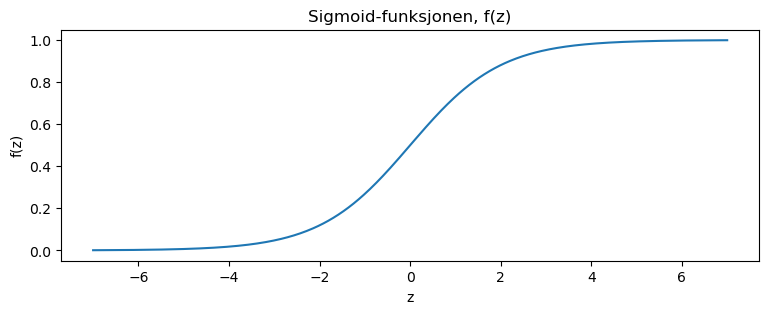

In [79]:
z = np.linspace(-7, 7, 500)
plt.figure(figsize=(9, 3))
plt.plot(z, sigmoid(z))
plt.title("Sigmoid-funksjonen, f(z)")
plt.xlabel("z")
plt.ylabel("f(z)")
plt.savefig("../figures/sigmoid.pdf", format="pdf")

### Notater
Hva gjør denne funksjonen godt egnet til å svare på ja/nei-spørsmål?
- Definisjonsmengden til funksjonen er intervallet (0, 1)
- Dermed kan man tolke funksjonsverdien som sannsynligheten for et utfall. 
- Man kan bestemme en beslutningsregel. Det som gir mest mening er å "akseptere" utfallet med størst sannsynlighet.

## 2b) Implementer logistisk regresjon og tren modellen

### Notater
- Implementering finnes i methods.py
- Testing i testing.ipynb

## 2c) Teste implementeringen på datasettet

In [80]:
from methods import fit_model
from sklearn.metrics import accuracy_score
from methods import output

Fit modell:

In [81]:
print(type(X_train))
print(type(y_train))

print(X_train.dtype)
print(y_train.dtype)

print(X_train.shape)
print(y_train.shape)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
object
int64
(712, 12)
(712,)


In [82]:
X_train = np.asarray(X_train, dtype=float)

In [83]:
seed = 270401
eta = 0.001
N = 10000
W, b = fit_model(X_train, y_train, seed, eta, n_iters=N)

Fullført 1000 steg av 10000
Fullført 2000 steg av 10000
Fullført 3000 steg av 10000
Fullført 4000 steg av 10000
Fullført 5000 steg av 10000
Fullført 6000 steg av 10000
Fullført 7000 steg av 10000
Fullført 8000 steg av 10000
Fullført 9000 steg av 10000
Fullført 10000 steg av 10000


Prediker på val-data

In [84]:
print(f"W shape: {W.shape}")
print(f"b shape: {b.shape}")
print(b)

W shape: (12, 1)
b shape: (1,)
[0.20098373]


In [85]:
X_val = np.asarray(X_val, dtype=float)
y_hat = output(X_val, W, b)
y_hat = np.round(y_hat)

acc_model = accuracy_score(y_true=y_val.reshape(-1, 1), y_pred=y_hat)

# Model som antar at alle dør:
y_all = np.zeros(len(y_val))
acc_all = accuracy_score(y_true=y_val, y_pred=y_all)

print(f"Prediksjons-accuracy, logistisk regresjon: ")
print(f"Læringsrate: {eta}")
print(f"Antall iterasjoner: {N}")
print(f"Accuracy score: {np.round(acc_model, 4)}")
print(f"Accuracy score for modell som predikerer at ingen overlever: {np.round(acc_all, 4)}")

Prediksjons-accuracy, logistisk regresjon: 
Læringsrate: 0.001
Antall iterasjoner: 10000
Accuracy score: 0.7709
Accuracy score for modell som predikerer at ingen overlever: 0.6145


### Notater
- Shapes er veldig viktige. Ulike shapes gir broadcasting i numpy, som fører til at man får tunge, alt for store operasjoner og feil resultat. 

# Oppgave 3

## 3a) Beslutningstre med maksdypbe 3

In [86]:
from sklearn import tree

Sjekk at data ser bra ut

In [87]:
print(f"X_train shape: {X_train.shape}")
print(f"X_train datatype: {X_train.dtype}")
print(f"X_val shape: {X_val.shape}")
print(f"X_val datatype: {X_val.dtype}")
print(f"y_train shape: {y_train.shape}")
print(f"y_train datatype: {y_train.dtype}")
print(f"y_val shape: {y_val.shape}")
print(f"y_val datatype: {y_val.dtype}")


X_train shape: (712, 12)
X_train datatype: float64
X_val shape: (179, 12)
X_val datatype: float64
y_train shape: (712,)
y_train datatype: int64
y_val shape: (179,)
y_val datatype: int64


Transformer y-ene for å unngå shape-problemer:

In [88]:
y_train = y_train.reshape(-1, 1)
y_val = y_val.reshape(-1, 1)
print(f"y_train shape: {y_train.shape}")
print(f"y_train datatype: {y_train.dtype}")
print(f"y_val shape: {y_val.shape}")
print(f"y_val datatype: {y_val.dtype}")

y_train shape: (712, 1)
y_train datatype: int64
y_val shape: (179, 1)
y_val datatype: int64


In [89]:
tre = tree.DecisionTreeClassifier(max_depth=3)
tre = tre.fit(X_train, y_train)

## 3b) Test treet på test-data (val-data)

In [90]:
y_hat=tre.predict(X_val)
acc_tre = accuracy_score(y_true=y_val, y_pred=y_hat)
print(f"Accuracy score, beslutningstre med maks dybde 3: {np.round(acc_tre, 4)}")


Accuracy score, beslutningstre med maks dybde 3: 0.8045


## 3c) Plot treet

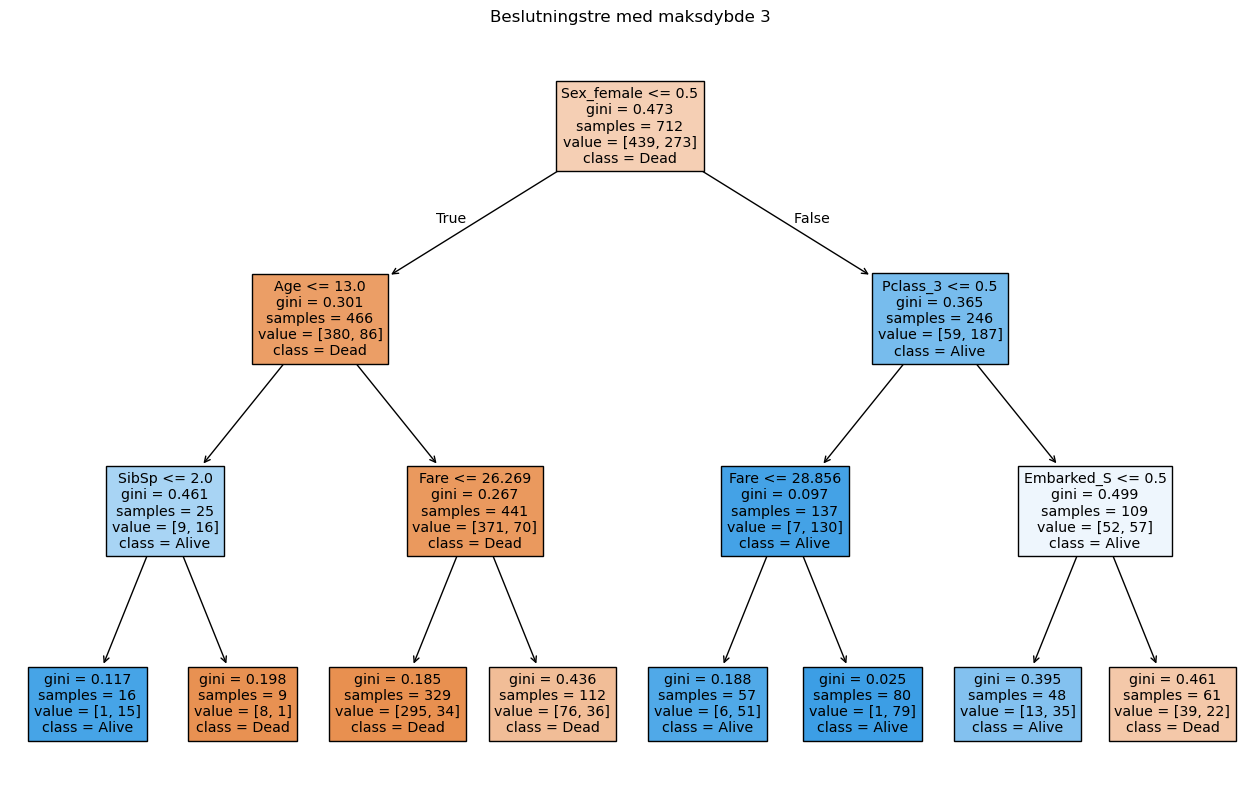

In [91]:
plt.figure(figsize=(16,10))
tree.plot_tree(tre, max_depth=3, feature_names=X_df.columns, class_names=["Dead", "Alive"], filled=True)
plt.title("Beslutningstre med maksdybde 3")
plt.savefig("../figures/beslutningstre_3.pdf", format="pdf")

### Notater
- gini måler hvor "ren" noden er. Gir ikke så mye mening.
- samples måler antall treningsobservasjoner som havner i den respektive noden
- value viser fordelingen av klasser i noden
- class er klassen treet vil predikere i denne noden

Hva forgreiningene sier:
- $\textbf{Nivå 1}$:
- - $\textbf{Node 1}$: Treet sjekker om personen er mann eller kvinne.
- $\textbf{Nivå 2}$:
- - $\textbf{Node 1}$: Sjekker om personen har billettklasse 3.
- - $\textbf{Node 2}$: Sjekker om personen er under 13 år.
- $\textbf{Nivå 3}$:
- - $\textbf{Node 1}$: Sjekker om billetten til personen kostet under 28.856
- - $\textbf{Node 2}$: Sjekker om personen ikke steg ombord i Southampton
- - $\textbf{Node 3}$: Sjekker om personen hadde 2 eller færre søsken eller partnere om bord
- - $\textbf{Node 4}$: Sjekker om personen betalte mindre enn 26.269 for billetten.

Hvilke personer sier treet at vil overleve?
- Kvinner med billettklasse 3, som ikke gikk på i Southampton
- Kvinner som ikke har billettklasse 3, som betalte mer enn 28.856 for billetten
- Kvinner som ikka har billettklasse 3, som betalte mindre nn 28.856 for billetten
- Menn under 13 som har færre enn 2 søsken eller partnere om bord. 

## 3d) Hvordan maksdybde påvirker accuracy

In [92]:
maksybder = np.arange(1, 11, 1)
accuracies_val = []
accuracies_train = []

for dybde in maksybder:
    tre = tree.DecisionTreeClassifier(max_depth=dybde)
    tre = tre.fit(X_train, y_train)
    # Valideringsdata
    y_hat_val = tre.predict(X_val)
    acc_val = accuracy_score(y_true=y_val, y_pred=y_hat_val)
    accuracies_val.append(acc_val)
    # Treningsdata (sjekke overfitting)
    y_hat_train = tre.predict(X_train)
    acc_test = accuracy_score(y_true=y_train, y_pred=y_hat_train)
    accuracies_train.append(acc_test)

accuracies_val=np.round(accuracies_val, 4)
# print(accuracies)
for dybde in maksybder:
    print(f"Accuracy med maksdybde {dybde}: {accuracies_val[dybde-1]}")
    

Accuracy med maksdybde 1: 0.7486
Accuracy med maksdybde 2: 0.7374
Accuracy med maksdybde 3: 0.8045
Accuracy med maksdybde 4: 0.8101
Accuracy med maksdybde 5: 0.8101
Accuracy med maksdybde 6: 0.8101
Accuracy med maksdybde 7: 0.8045
Accuracy med maksdybde 8: 0.7989
Accuracy med maksdybde 9: 0.7933
Accuracy med maksdybde 10: 0.7933


Plotter trenings vs validerings accuracy

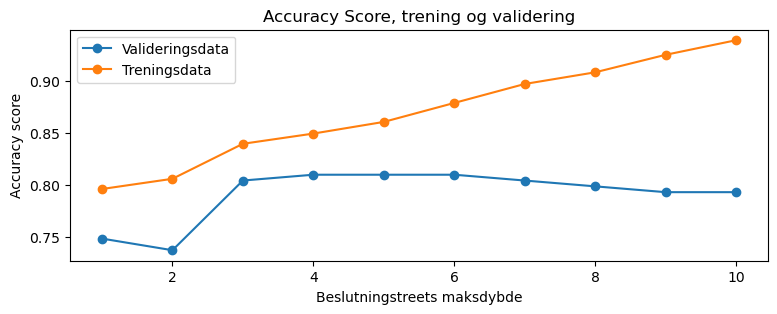

In [93]:
plt.figure(figsize=(9,3))
plt.plot(maksybder, accuracies_val,marker="o", label = "Valideringsdata")
plt.plot(maksybder, accuracies_train, marker="o", label="Treningsdata")
plt.title("Accuracy Score, trening og validering")
plt.ylabel("Accuracy score")
plt.xlabel("Beslutningstreets maksdybde")
plt.legend()
plt.savefig("../figures/acc_score_maksdybde_10.pdf", format="pdf")

### Notater
- Accuracy ser ut til å nå et platå på om lag 0.81 for økende maksdybder. 
- Plotter accuracy for validering og trening, får resultater som forventet.

## Oppgave 4

### 4a) Random forest-modell

In [94]:
from sklearn.ensemble import RandomForestClassifier

In [95]:
skog = RandomForestClassifier(n_estimators=100, max_features="sqrt", random_state=seed)
skog.fit(X_train, y_train.ravel())
print(f"Skog med {skog.n_estimators} trær, max_features: {skog.max_features}")


Skog med 100 trær, max_features: sqrt


### 4b) Test modellen på testdataene

In [96]:
prediksjoner = skog.predict(X_val)
noyaktighet = skog.score(X_val, y_val)
print(f"Nøyaktighet: {np.round(noyaktighet, 4)}")

Nøyaktighet: 0.7933


### 4c) Underøke hvordan antall weak learners påvirker nøyaktigheten

In [97]:
weak_learners = [1, 3, 5, 10, 20, 50, 100, 200, 500, 1000]
accuracies = []
for n in weak_learners:
    rf = RandomForestClassifier(n_estimators = n, random_state=seed)
    rf.fit(X_train, y_train.ravel())
    accuracies.append(rf.score(X_val, y_val))


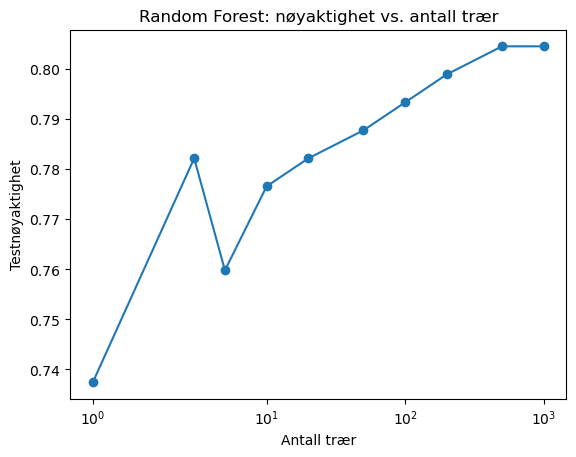

In [98]:
plt.plot(weak_learners, accuracies, marker="o")
plt.xlabel("Antall trær")
plt.ylabel("Testnøyaktighet")
plt.title("Random Forest: nøyaktighet vs. antall trær")
plt.xscale("symlog")
plt.show()

### 4d) Feature importance og partial dependence for beste modell

Beste modell: 500 trær

<BarContainer object of 12 artists>

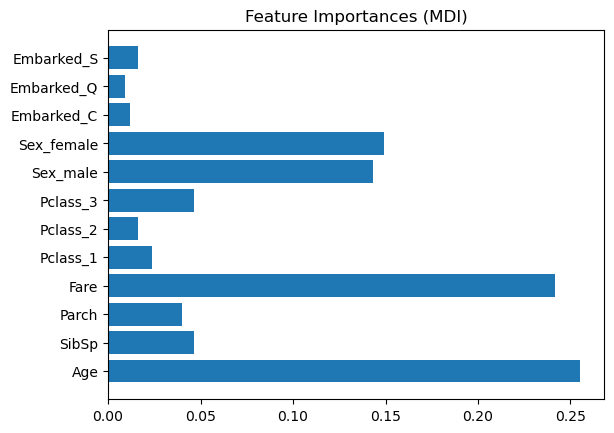

In [99]:
n = 500
skog = RandomForestClassifier(n_estimators = n, random_state=seed)
skog.fit(X_train, y_train.ravel())
importance = skog.feature_importances_
indices = np.argsort(importance)


plt.title("Feature Importances (MDI)")
plt.barh(covariates, importance)


In [100]:
from sklearn.inspection import PartialDependenceDisplay

In [101]:
PartialDependenceDisplay.from_estimator(skog, X_val, features=X_df.columns)

ValueError: Feature 'Age' not in feature_names